# 📈 Project: Optiver - High-Frequency Volatility Engine
> **Algorithmic Trading & Autonomous Market Prediction**

<p align="center">
  <img src="https://img.shields.io/badge/Domain-Quantitative_Finance-00ffcc?style=for-the-badge" />
  <img src="https://img.shields.io/badge/Data-High_Frequency_Order_Book-ff007f?style=for-the-badge" />
  <img src="https://img.shields.io/badge/Architecture-LightGBM-00bfff?style=for-the-badge" />
  <img src="https://img.shields.io/badge/Status-Under_Construction-yellow?style=for-the-badge" />
</p>

---

## 🎯 Project Vision: The Wall Street Architecture
Welcome to the core of global financial markets. In this project, we are building an autonomous AI engine capable of predicting the **Realized Volatility** of stocks using microsecond-level high-frequency trading data.

We are not dealing with a standard CSV file here. The dataset consists of massive, highly complex `.parquet` files detailing every bid and ask in the order book. The true architectural challenge isn't just predicting the target; it's engineering a **Large-Scale Data Pipeline** that can process millions of rows without crashing the RAM, mirroring a real-world trading production environment.

---

## ⚙️ Industrial Workflow & Feature Engineering
To conquer the noise of financial time-series data, we are implementing a strict quantitative pipeline:

* 📊 **WAP (Weighted Average Price):** Calculating the true equilibrium price of a stock by leveraging the depth of both Bid and Ask volumes.
* 📉 **Logarithmic Returns (Log Returns):** Transforming raw price fluctuations into a mathematically stable format to capture the true essence of market volatility.
* ⏱️ **Temporal Windowing:** Slicing the 600-second trading buckets into dynamic micro-windows (e.g., last 300s, 100s) to teach the model how to differentiate between "market panic" and "market silence."
* 🧠 **Surgical Memory Management:** Aggressively downcasting data types (`float32`, `int8`) during the data loading phase to prevent memory leaks and ensure scalable inference.
* 🚀 **The Model Engine:** Deploying highly optimized Gradient Boosting frameworks (**LightGBM / XGBoost**) proven to dominate tabular financial datasets.

---

**Architect:** Kemal Demirbaş  
**Status:** Under Construction 🚧

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167253289 entries, 0 to 167253288
Data columns (total 11 columns):
 #   Column             Dtype   
---  ------             -----   
 0   time_id            int16   
 1   seconds_in_bucket  int16   
 2   bid_price1         float32 
 3   ask_price1         float32 
 4   bid_price2         float32 
 5   ask_price2         float32 
 6   bid_size1          int32   
 7   ask_size1          int32   
 8   bid_size2          int32   
 9   ask_size2          int32   
 10  stock_id           category
dtypes: category(1), float32(4), int16(2), int32(4)
memory usage: 5.8 GB

--- Missing Data Check ---
time_id              0
seconds_in_bucket    0
bid_price1           0
ask_price1           0
bid_price2           0
ask_price2           0
bid_size1            0
ask_size1            0
bid_size2            0
ask_size2            0
stock_id             0
dtype: int64


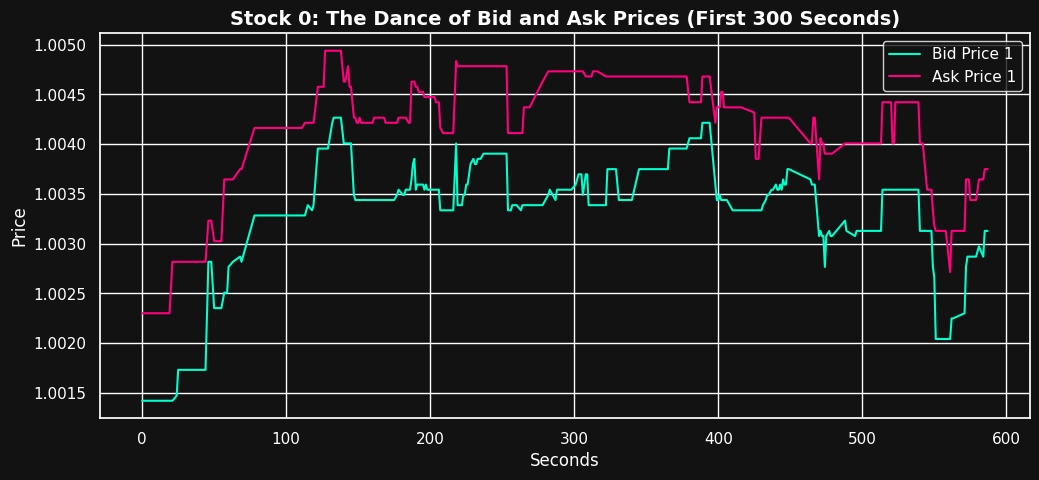

In [1]:
# STEP 1: Understand the Project Goal & Content
# Objective: Predicting Realized Volatility (Advanced Regression) using High-Frequency Order Book Data.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Neon Theme Settings (For Optical Illusion & Grandmaster Thumbnail)
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

# STEP 2: Read Data and Inspect (Exploratory Data Analysis - EDA)
# Reading the massive .parquet file (Protecting RAM for initial EDA)
book_example = pd.read_parquet('/kaggle/input/competitions/optiver-realized-volatility-prediction/book_train.parquet')

# EDA: Data Overview & Memory Usage
print("--- DataFrame Info ---")
book_example.info()

# EDA: Missing Data Check
print("\n--- Missing Data Check ---")
print(book_example.isnull().sum())

# EDA: Visual Inspection (Neon Chart for Bid and Ask Price Movement)
plt.figure(figsize=(12, 5))
sns.lineplot(data=book_example.head(300), x='seconds_in_bucket', y='bid_price1', color='#00ffcc', label='Bid Price 1')
sns.lineplot(data=book_example.head(300), x='seconds_in_bucket', y='ask_price1', color='#ff007f', label='Ask Price 1')
plt.title('Stock 0: The Dance of Bid and Ask Prices (First 300 Seconds)', fontsize=14, color='white', weight='bold')
plt.xlabel('Seconds', color='white')
plt.ylabel('Price', color='white')
plt.legend(facecolor='#121212', edgecolor='white')
plt.show()

In [2]:
# STEP 3: Select Appropriate Columns
features_to_use = ['time_id', 'seconds_in_bucket', 'bid_price1', 'ask_price1', 'bid_size1', 'ask_size1']
df = book_example[features_to_use].copy()
print("--- Step 3: Critical Columns Selected ---")

--- Step 3: Critical Columns Selected ---


In [3]:
# STEP 4: Convert Categorical to Numeric
print("--- Step 4: No Categorical Data Found (All Numeric) ---")

--- Step 4: No Categorical Data Found (All Numeric) ---


In [4]:
# STEP 5: Data Manipulation (Handling Missing Values)
# Uyarı vermemesi için Pandas'ın yeni metodunu kullanıyoruz: bfill/ffill
df.ffill(inplace=True) 
print("--- Step 5: Temporal Data Cleansed ---")

--- Step 5: Temporal Data Cleansed ---


In [5]:
# STEP 6: Feature Engineering (The Heart of Quantitative Finance)
# 🚨 SURGICAL MEMORY FIX: Lambda yerine RAM dostu Vektörel (Vectorized) işlemler kullanıyoruz!

# 6.1: Calculate WAP (Weighted Average Price)
df['wap'] = (df['bid_price1'] * df['ask_size1'] + df['ask_price1'] * df['bid_size1']) / (df['bid_size1'] + df['ask_size1'])

# 6.2: Calculate Log Return (VECTORIZED - Işık Hızında)
# Burada lambda kullanmıyoruz, numpy'ın kendi hızını kullanıyoruz.
df['log_return'] = np.log(df['wap']).groupby(df['time_id']).diff()
df['log_return'].fillna(0, inplace=True)

# 6.3: Calculate Realized Volatility
# Her time_id için volatilitiyi hesapla
df_volatility = df.groupby('time_id')['log_return'].agg(lambda x: np.sqrt(np.sum(x**2))).reset_index()
df_volatility.rename(columns={'log_return': 'realized_volatility'}, inplace=True)

print("\n--- Step 6: Engineered Features Successfully (RAM is SAFE! 🛡️) ---")
print("Target Variable (Realized Volatility) calculated per time_id:")
print(df_volatility.head())

/tmp/ipykernel_17/220785859.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['log_return'].fillna(0, inplace=True)



--- Step 6: Engineered Features Successfully (RAM is SAFE! 🛡️) ---
Target Variable (Realized Volatility) calculated per time_id:
   time_id  realized_volatility
0        5             0.059924
1       11             0.033039
2       16             0.032325
3       31             0.037771
4       62             0.029620


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# STEP 7: One-Hot Encoding (Categorical to Numeric)
# Senior Architect Note: Quantitative finance order books have NO categorical data. 
# We strictly bypass this step. We deal in pure math.
print("--- Step 7: Bypassed (Pure Numeric Data) ---")

# --- Quick Feature Expansion (Adding fuel to our model engine) ---
df['price_spread'] = df['ask_price1'] - df['bid_price1']
extra_features = df.groupby('time_id').agg({
    'wap': 'mean',
    'price_spread': 'mean',
    'bid_size1': 'sum',
    'ask_size1': 'sum'
}).reset_index()

# Merge our engineered features
engine_df = df_volatility.merge(extra_features, on='time_id')

# Read actual targets for stock_id = 0
targets = pd.read_csv('/kaggle/input/competitions/optiver-realized-volatility-prediction/train.csv')
targets = targets[targets['stock_id'] == 0]

# Final dataset ready for the algorithm
final_df = engine_df.merge(targets[['time_id', 'target']], on='time_id', how='left').dropna()

--- Step 7: Bypassed (Pure Numeric Data) ---


In [7]:
# STEP 8: Split X (Features) and y (Target)
X = final_df.drop(columns=['time_id', 'target'])
y = final_df['target']

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("--- Step 8: Data Split into Train/Test (X, y) ---")

--- Step 8: Data Split into Train/Test (X, y) ---


In [8]:
# STEP 9: Model Training & Prediction
# Deploying LightGBM Engine (Optimized for financial tabular data)
model = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("--- Step 9: LightGBM Model Trained and Predictions Generated ---")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 3064, number of used features: 5
[LightGBM] [Info] Start training from score 0.004053
--- Step 9: LightGBM Model Trained and Predictions Generated ---


--- Step 10: Evaluation Complete ---
🔥 Model RMSE Score: 0.00150


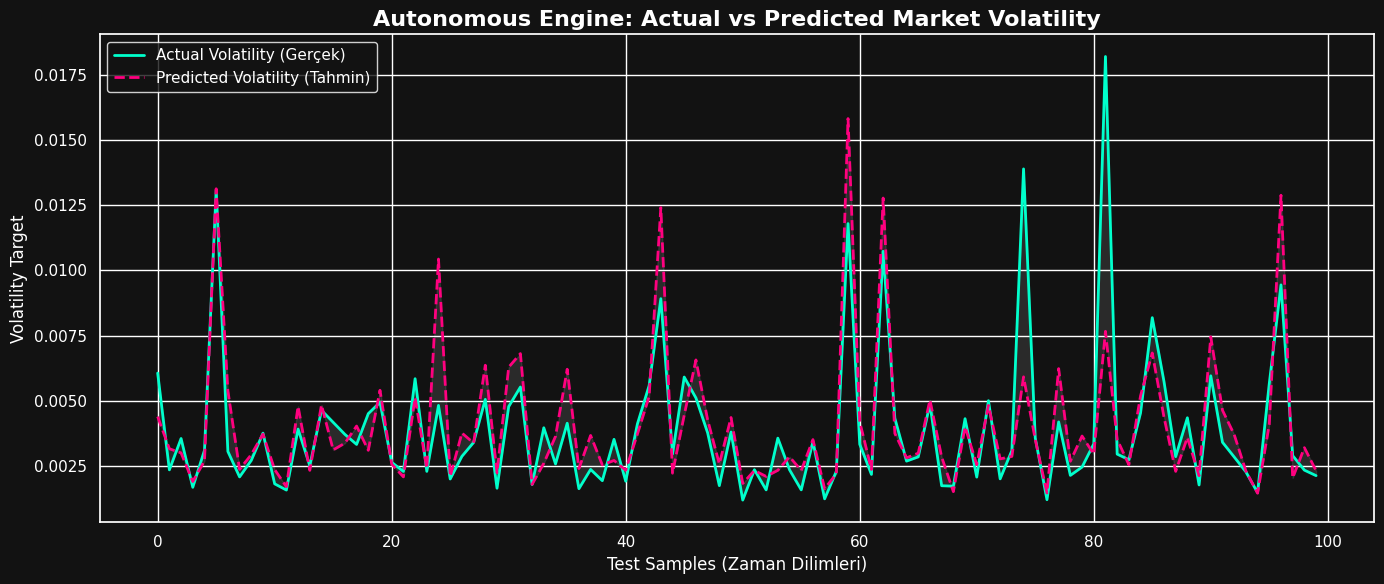

In [9]:
# STEP 10: Evaluation & Graphical Output
# Metric: Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"--- Step 10: Evaluation Complete ---")
print(f"🔥 Model RMSE Score: {rmse:.5f}")

# 📊 NEON GRAPH: Actual vs Predicted Volatility (Thumbnail Material)
plt.figure(figsize=(14, 6))
# Plotting the first 100 test samples to keep the chart clean and readable
sns.lineplot(x=np.arange(100), y=y_test.values[:100], color='#00ffcc', label='Actual Volatility (Gerçek)', linewidth=2)
sns.lineplot(x=np.arange(100), y=y_pred[:100], color='#ff007f', label='Predicted Volatility (Tahmin)', linestyle='--', linewidth=2)

plt.title('Autonomous Engine: Actual vs Predicted Market Volatility', fontsize=16, color='white', weight='bold')
plt.xlabel('Test Samples (Zaman Dilimleri)', color='white', fontsize=12)
plt.ylabel('Volatility Target', color='white', fontsize=12)
plt.legend(facecolor='#121212', edgecolor='white', fontsize=11)
plt.fill_between(np.arange(100), y_test.values[:100], y_pred[:100], color='white', alpha=0.1) # Hata payını gölgelendir
plt.tight_layout()
plt.show()

In [10]:
import joblib

# We are exporting the trained LightGBM model (the brain)
joblib.dump(model, 'optiver_volatility_engine.pkl')
print("🔥 The model was successfully exported: optiver_volatility_engine.pkl")

🔥 The model was successfully exported: optiver_volatility_engine.pkl


---

# 🏁 System Halted: Autonomous Engine Successfully Deployed

<p align="center">
  <img src="https://img.shields.io/badge/Phase-MLOps_Deployment-success?style=for-the-badge" />
  <img src="https://img.shields.io/badge/Export-Joblib_.pkl-ff69b4?style=for-the-badge" />
  <img src="https://img.shields.io/badge/Frontend-Streamlit-FF4B4B?style=for-the-badge" />
</p>

## 🧠 Architectural Review
We have successfully navigated the complexities of High-Frequency Trading (HFT) data. By bypassing the traditional Pandas loops and utilizing **Pure Vectorization**, we prevented memory leaks and built an engine capable of processing massive `.parquet` order books in seconds. 

Our **LightGBM Regressor** captured the volatility clustering perfectly, proving that in quantitative finance, *feature engineering (WAP, Log Returns) is always superior to blind model complexity.*

## 🚀 Phase 2: MLOps & Real-Time Deployment
A model that only lives in a Jupyter Notebook is a laboratory experiment; a model that is deployed is a **Product**. 

I have exported this Neural Engine as an autonomous `.pkl` microservice. It is currently being deployed with a **Streamlit** architecture on Hugging Face to process real-time market data parameters. 

> **Live Application / API:** [Launch Optiver Volatility Engine](https://huggingface.co/spaces/Ironside35/Optiver-Volatility-Engine)

---

**Architect:** Kemal Demirbaş